# Preprocessing (Alignment, Filtering, Normalization)

## Load and Label Data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# General pose dynamics utilities
from pose_dynamics.preprocessing.pose_preprocessing import *

# Mirror Game dataset-specific functions and constants
from pathlib import Path
from pose_dynamics.projects.mirror_game.pipeline import *

# Set this to raw Mirror Game CSV directory
DATA_DIR = Path("/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/raw")

# Load, resample to TARGET_RATE, and temporally align all P1/P2 pairs
trial_groups, pair_trials, bad_files = load_and_align_trials_from_dir(
    DATA_DIR,
    target_rate=30.0,
    verbose=True,
)
pairs = {pair_id for (pair_id, trial_id) in trial_groups.keys()}


print(f"Number of complete trials (P#_T# with both P1 & P2): {len(trial_groups)}")
print("Number of pairs:", len(pairs))
print(f"Number of unmatched / bad filenames:                     {len(bad_files)}")

if bad_files:
    print("\nExamples of unmatched filenames:")
    for name in bad_files[:10]:
        print("  -", name)

rows = []
for (pair_id, trial_id), parties in trial_groups.items():
    for party in ("P1", "P2"):
        rows.append({
            "pair_trial": f"{pair_id}_{trial_id}",
            "party": party,
        })

df_trials = pd.DataFrame(rows)

df_cond = add_experimental_conditions(
    df_trials,
    conditions_csv="Mirror_Game_Conditions.csv",
    verbose=True,
)

df_cond.sort_values(["Pair", "Trial", "party"]).head(40)

Found 216 trial entries, 2 unmatched files
Loaded 216 complete trial pairs
Number of complete trials (P#_T# with both P1 & P2): 216
Number of pairs: 18
Number of unmatched / bad filenames:                     2

Examples of unmatched filenames:
  - rename_files.csv
  - rename_log.csv

Merge summary:
  Rows before: 432
  Rows after:  432
  Conditions:  ['uni' 'f2f' 'b2b']
  Roles:       ['Follower' 'Leader']


,pair_trial,party,Pair,Trial,Condition,Leader,Role
6,P001_T1,P1,1,1,b2b,P1,Leader
7,P001_T1,P2,1,1,b2b,P1,Follower
8,P001_T2,P1,1,2,uni,P1,Leader
9,P001_T2,P2,1,2,uni,P1,Follower
10,P001_T3,P1,1,3,f2f,P1,Leader
11,P001_T3,P2,1,3,f2f,P1,Follower
12,P001_T4,P1,1,4,uni,P1,Leader
13,P001_T4,P2,1,4,uni,P1,Follower
14,P001_T5,P1,1,5,f2f,P1,Leader
15,P001_T5,P2,1,5,f2f,P1,Follower


## Alignment

In [2]:
# ---------------------------------------------------------
# Build list of centred sequences from all trials
# ---------------------------------------------------------
all_seqs = []
trial_order = []  # to keep the mapping back to trial_groups

for (pair_id, trial_id), parties in trial_groups.items():
    for party in ("P1", "P2"):
        fname, df, xyz_cols = parties[party]

        # (T, n_points, 3) in original camera coords
        seq = df_to_pose_tensor(df, xyz_cols, n_keypoints=38, dim=3)

        # centre on pelvis (joint 0) – matches canonicalise_mean_pose assumption
        seq_centered = seq - seq[:, PELVIS_IDX:PELVIS_IDX+1, :]

        all_seqs.append(seq_centered)
        trial_order.append((pair_id, trial_id, party))

print(f"Collected {len(all_seqs)} sequences for template building.")

# ---------------------------------------------------------
# Build global canonical template (body-centred frame)
# ---------------------------------------------------------
template = build_template_with_canonicalisation(all_seqs, n_points=38)
print("Global template shape:", template.shape)

# ---------------------------------------------------------
# Canonicalise every trial to the global template
# ---------------------------------------------------------
for seq_centered, (pair_id, trial_id, party) in zip(all_seqs, trial_order):
    fname, df, xyz_cols = trial_groups[(pair_id, trial_id)][party]

    canon_seq = canonicalise_trial(seq_centered, template)  # (T, 38, 3)

    # flatten back to (T, 114) and replace XYZ columns in the dataframe
    flat = canon_seq.reshape(canon_seq.shape[0], -1)
    df.loc[:, xyz_cols] = flat

    # write back into trial_groups
    trial_groups[(pair_id, trial_id)][party] = (fname, df, xyz_cols)

print("Updated trial_groups with canonicalised (body-frame) coordinates.")


Collected 432 sequences for template building.
Global template shape: (38, 3)
Updated trial_groups with canonicalised (body-frame) coordinates.


In [3]:
(example_pair, example_trial), parties = next(iter(trial_groups.items()))
print(f"Example after canonicalisation: {example_pair}, {example_trial}")

p1_name, p1_df, p1_cols = parties["P1"]
p1_pose = df_to_pose_tensor(p1_df, p1_cols)

print("P1 pose tensor shape:", p1_pose.shape)
print("Mean over frames/keypoints (should be ≈ 0,0,0 except small drift):",
      p1_pose.mean(axis=(0,1)))


Example after canonicalisation: P001, T10
P1 pose tensor shape: (1038, 38, 3)
Mean over frames/keypoints (should be ≈ 0,0,0 except small drift): [ 0.00178517 -0.0054836  -0.05811366]


## Butterworth Filter

Using example: pair=P001, trial=T10
P1 raw shape: (1038, 114)
P1 filtered shape: (1038, 114)


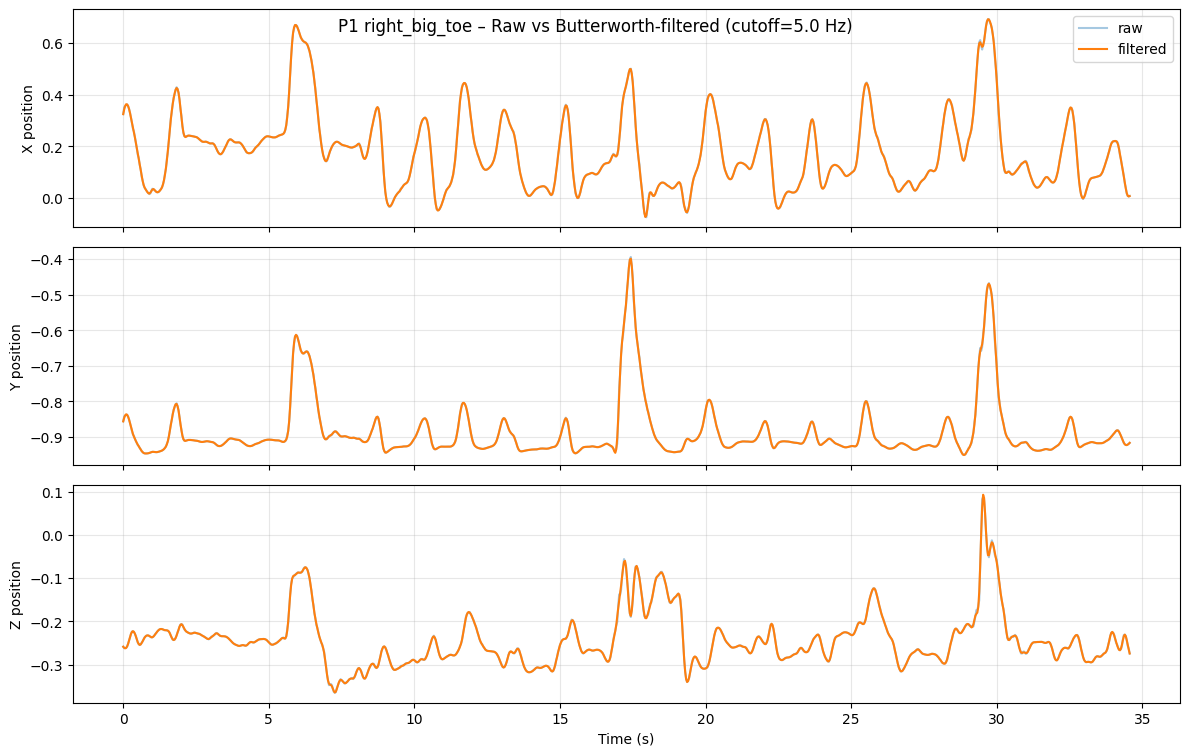

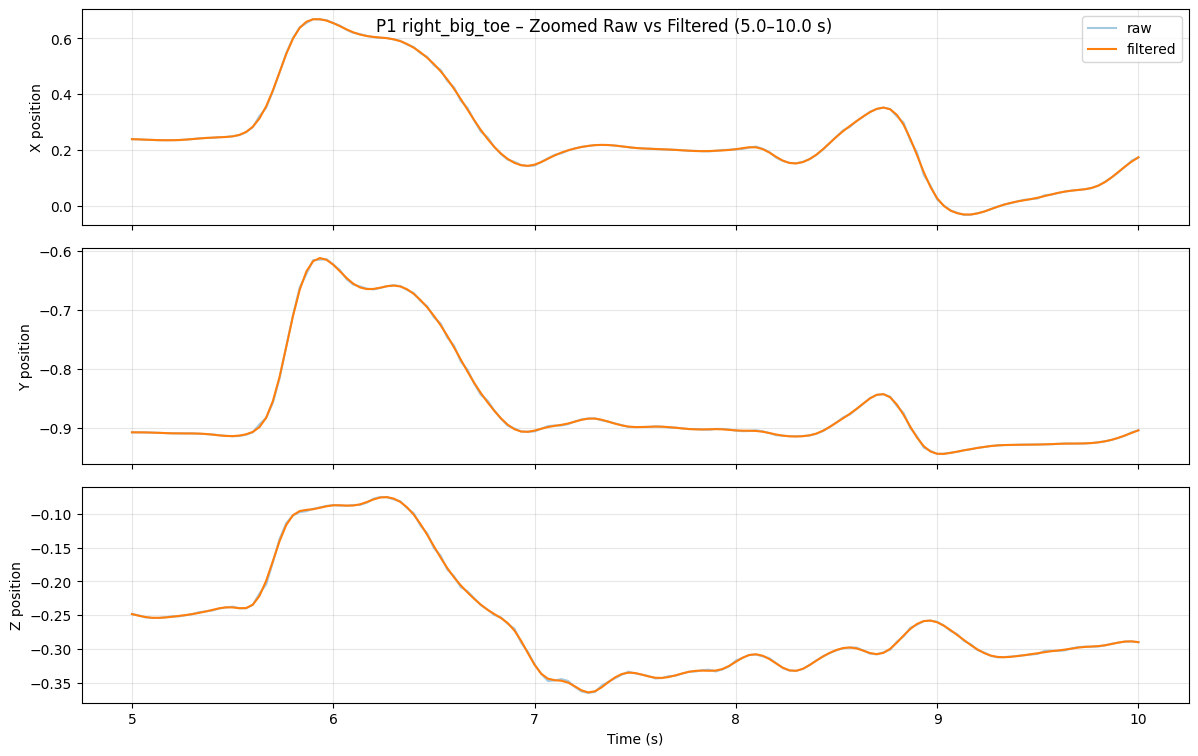

In [4]:
import numpy as np
import pandas as pd
from pose_dynamics.preprocessing.signal_cleaning import (
    butterworth_filter_dataframe,
)
from pose_dynamics.projects.mirror_game.pipeline import KEYPOINT_MAPPING

FPS = 30.0
CUTOFF_HZ = 5.0
FILTER_ORDER = 4

# Take the same example trial we used before
(example_pair, example_trial), parties = next(iter(trial_groups.items()))
print(f"Using example: pair={example_pair}, trial={example_trial}")

p1_name, p1_df, p1_cols = parties["P1"]

# Extract only XYZ pose columns
p1_xyz = p1_df[p1_cols]

# Apply Butterworth filter
p1_filt = butterworth_filter_dataframe(
    p1_xyz,
    fs=FPS,
    cutoff_hz=CUTOFF_HZ,
    order=FILTER_ORDER,
    btype="low",
)

print("P1 raw shape:", p1_xyz.shape)
print("P1 filtered shape:", p1_filt.shape)

# Choose a keypoint to visualize
KP_INDEX = 25  # right_hand; change this if you want a different joint
kp_label = KEYPOINT_MAPPING[KP_INDEX]

# Time axis
t = p1_df["time_s"].to_numpy()

# Get raw and filtered trajectories for this keypoint
raw_kp = p1_xyz[[f"x{KP_INDEX}", f"y{KP_INDEX}", f"z{KP_INDEX}"]].to_numpy()
filt_kp = p1_filt[[f"x{KP_INDEX}", f"y{KP_INDEX}", f"z{KP_INDEX}"]].to_numpy()

coord_labels = ["X", "Y", "Z"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"P1 {kp_label} – Raw vs Butterworth-filtered (cutoff={CUTOFF_HZ} Hz)", y=0.93)

for d, ax in enumerate(axes):
    ax.plot(t, raw_kp[:, d], alpha=0.4, label="raw")
    ax.plot(t, filt_kp[:, d], linewidth=1.5, label="filtered")
    ax.set_ylabel(f"{coord_labels[d]} position")
    ax.grid(True, alpha=0.3)
    if d == 0:
        ax.legend(loc="upper right")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

t_start, t_end = 5.0, 10.0
mask = (t >= t_start) & (t <= t_end)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"P1 {kp_label} – Zoomed Raw vs Filtered ({t_start:.1f}–{t_end:.1f} s)", y=0.93)

for d, ax in enumerate(axes):
    ax.plot(t[mask], raw_kp[mask, d], alpha=0.4, label="raw")
    ax.plot(t[mask], filt_kp[mask, d], linewidth=1.5, label="filtered")
    ax.set_ylabel(f"{coord_labels[d]} position")
    ax.grid(True, alpha=0.3)
    if d == 0:
        ax.legend(loc="upper right")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Save all normalized/preprocessed data

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

from pose_dynamics.preprocessing.signal_cleaning import (
    butterworth_filter_dataframe,
    normalize_dataframe,
)
from pose_dynamics.projects.mirror_game.pipeline import add_experimental_conditions

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
FPS = 30.0
CUTOFF_HZ = 5.0
FILTER_ORDER = 4

OUTPUT_CSV = Path("/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed.csv")
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Condition metadata table
# ------------------------------------------------------------
rows = []
for (pair_id, trial_id), parties in trial_groups.items():
    for party in ("P1", "P2"):
        rows.append({
            "pair_trial": f"{pair_id}_{trial_id}",
            "party": party,
        })

df_trials = pd.DataFrame(rows)

df_cond = add_experimental_conditions(
    df_trials,
    conditions_csv="Mirror_Game_Conditions.csv",
    verbose=True,
)

meta_lookup = df_cond.set_index(["pair_trial", "party"])

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
HIP_INDICES = [18, 19]

def df_to_tensor(df, xyz_cols):
    arr = df[xyz_cols].to_numpy(dtype=float)
    T, F = arr.shape
    return arr.reshape(T, 38, 3)

def tensor_to_df(tensor, xyz_cols):
    return pd.DataFrame(tensor.reshape(tensor.shape[0], -1), columns=xyz_cols)

def center_on_hips(tensor):
    hip_center = tensor[:, HIP_INDICES, :].mean(axis=1, keepdims=True)
    return tensor - hip_center

# ------------------------------------------------------------
# Build one giant dataframe
# ------------------------------------------------------------
all_rows = []  # we'll concat once at the end

for (pair_id, trial_id), parties in trial_groups.items():
    for party in ("P1", "P2"):

        pair_trial = f"{pair_id}_{trial_id}"
        meta = meta_lookup.loc[(pair_trial, party)]

        fname, df_aligned, xyz_cols = parties[party]

        # --- Filter ---
        xyz_df = df_aligned[xyz_cols]
        xyz_filt = butterworth_filter_dataframe(
            xyz_df,
            fs=FPS,
            cutoff_hz=CUTOFF_HZ,
            order=FILTER_ORDER,
            btype="low",
        )

        # --- Center ---
        tensor = df_to_tensor(xyz_filt, xyz_filt.columns)
        tensor_centered = center_on_hips(tensor)
        xyz_centered_df = tensor_to_df(tensor_centered, xyz_filt.columns)

        # --- Build block ---
        n = len(xyz_centered_df)

        block = pd.concat([
            pd.DataFrame({"time_s": df_aligned["time_s"].to_numpy()}),
            xyz_centered_df,
            pd.DataFrame({
                "pair_trial": [pair_trial] * n,
                "pair_id": [pair_id] * n,
                "trial_id": [trial_id] * n,
                "party": [party] * n,
                "Pair": [meta["Pair"]] * n,
                "Trial": [meta["Trial"]] * n,
                "Condition": [meta["Condition"]] * n,
                "Leader": [meta["Leader"]] * n,
                "Role": [meta["Role"]] * n,
            })
        ], axis=1)

        all_rows.append(block)

# ------------------------------------------------------------
# Save one unified CSV
# ------------------------------------------------------------
full_df = pd.concat(all_rows, axis=0, ignore_index=True)
full_df.to_csv(OUTPUT_CSV, index=False)

print(f"[done] Saved unified dataset: {OUTPUT_CSV}")
print("Shape:", full_df.shape)
print(full_df.head())



Merge summary:
  Rows before: 432
  Rows after:  432
  Conditions:  ['uni' 'f2f' 'b2b']
  Roles:       ['Follower' 'Leader']
[done] Saved unified dataset: /Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed.csv
Shape: (455138, 124)
     time_s        x0        y0        z0        x1        y1        z1  \
0  0.000000 -0.000488  0.053283  0.007361 -0.001052  0.115829  0.016006   
1  0.033333 -0.000511  0.053318  0.007088 -0.001105  0.115907  0.015412   
2  0.066667 -0.000493  0.053351  0.006840 -0.001069  0.115978  0.014872   
3  0.100000 -0.000395  0.053380  0.006619 -0.000858  0.116042  0.014389   
4  0.133333 -0.000184  0.053408  0.006406 -0.000401  0.116102  0.013926   

         x2        y2        z2  ...       z37  pair_trial  pair_id  trial_id  \
0  0.000446  0.231877  0.032813  ... -0.050248    P001_T10     P001       T10   
1  0.000818  0.232022  0.031674  ... -0.032085    P001_T10     P001       T10   
2  0.001306  0.2321

## Save Subset of Keypoints

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

from pose_dynamics.projects.mirror_game.pipeline import KEYPOINT_MAPPING
from pose_dynamics.viz.keypoint_viz import (
    plot_keypoints_interactive,
    plot_keypoints_with_indices_static,
)

# Local helper (since it's not in keypoint_viz)
def print_keypoint_table(mapping: dict):
    print("Index\tLabel")
    print("-" * 30)
    for idx in sorted(mapping.keys()):
        print(f"{idx:2d}\t{mapping[idx]}")

# ------------------------------------------------------------
# Use one representative trial to build a template pose
# ------------------------------------------------------------
(example_pair, example_trial), parties = next(iter(trial_groups.items()))
print(f"Using example: pair={example_pair}, trial={example_trial}")

# pick one party for visualization (P1)
fname, df_aligned, xyz_cols = parties["P2"]
print(f"P2 file: {fname}")
print(f"Aligned shape: {df_aligned.shape}")
print(f"#XYZ cols: {len(xyz_cols)}")

N_KEYPOINTS = 38
template = np.zeros((N_KEYPOINTS, 3), dtype=float)

for k in range(N_KEYPOINTS):
    template[k, 0] = df_aligned[f"x{k}"].mean()
    template[k, 1] = df_aligned[f"y{k}"].mean()
    template[k, 2] = df_aligned[f"z{k}"].mean()

print(f"\nTemplate pose shape: {template.shape} (n_keypoints, 3)")

print("\nKeypoint index → label mapping:")
print_keypoint_table(KEYPOINT_MAPPING)

print("\n" + "=" * 70)

# ------------------------------------------------------------
# Plot for presentation (raw-ish geometry, not z-scored)
# ------------------------------------------------------------
try:
    print("\nCreating interactive 3D visualization (hover to inspect indices/labels)...")
    fig = plot_keypoints_interactive(
        template,
        title=f"Mirror Game – Mean Pose Template (P1, {example_pair}_{example_trial})"
    )
except ImportError:
    print("\nplotly not available, using static matplotlib plot instead.")
    print("Install plotly for interactive plots: pip install plotly")
    plot_keypoints_with_indices_static(
        template,
        title=f"Mirror Game – Mean Pose Template (P1, {example_pair}_{example_trial})"
    )



Using example: pair=P001, trial=T10
P2 file: P001_T10_P2_pose_3d.csv
Aligned shape: (1038, 117)
#XYZ cols: 114

Template pose shape: (38, 3) (n_keypoints, 3)

Keypoint index → label mapping:
Index	Label
------------------------------
 0	pelvis
 1	spine_1
 2	spine_2
 3	spine_3
 4	neck
 5	nose
 6	left_eye
 7	right_eye
 8	left_ear
 9	right_ear
10	left_clavicle
11	right_clavicle
12	left_shoulder
13	right_shoulder
14	left_elbow
15	right_elbow
16	left_wrist
17	right_wrist
18	left_hip
19	right_hip
20	left_knee
21	right_knee
22	left_ankle
23	right_ankle
24	left_big_toe
25	right_big_toe
26	left_small_toe
27	right_small_toe
28	left_heel
29	right_heel
30	left_hand_thumb_4
31	right_hand_thumb_4
32	left_hand_index_1
33	right_hand_index_1
34	left_hand_middle_4
35	right_hand_middle_4
36	left_hand_pinky_1
37	right_hand_pinky_1


Creating interactive 3D visualization (hover to inspect indices/labels)...


In [8]:
import pandas as pd
from pathlib import Path
from pose_dynamics.projects.mirror_game.pipeline import KEYPOINT_MAPPING

# Path to unified preprocessed file
PREPROC_PATH = Path(
    "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed.csv"
)

df_all = pd.read_csv(PREPROC_PATH)
print(f"Loaded full dataset: {df_all.shape}")

# ------------------------------------------------------------
# Define keypoints of interest (you can edit these later)
# ------------------------------------------------------------
KEYPOINTS_OF_INTEREST = [
    22,          # left ankle
    23,         # right ankle
    16,        # left hand
    17,        # right hand
    5,         # nose
]

# Build mapping index → readable label
# Example: 14 → "left_wrist"
label_map = {idx: KEYPOINT_MAPPING[idx] for idx in KEYPOINTS_OF_INTEREST}

print("Selected keypoints:")
for idx, label in label_map.items():
    print(f"  {idx}: {label}")

# Build readable XYZ column names
readable_xyz_cols = []
for idx in KEYPOINTS_OF_INTEREST:
    base = label_map[idx]
    readable_xyz_cols.extend([
        f"{base}_x",
        f"{base}_y",
        f"{base}_z",
    ])

# Original XYZ columns
orig_xyz_cols = []
for idx in KEYPOINTS_OF_INTEREST:
    orig_xyz_cols.extend([f"x{idx}", f"y{idx}", f"z{idx}"])

# Always keep these metadata columns
meta_cols = [
    "time_s",
    "pair_trial", "pair_id", "trial_id", "party",
    "Pair", "Trial", "Condition", "Leader", "Role",
]

# Extract subset
df_subset = df_all[meta_cols + orig_xyz_cols].copy()

# Rename XYZ → readable names
rename_dict = {orig: new for orig, new in zip(orig_xyz_cols, readable_xyz_cols)}
df_subset = df_subset.rename(columns=rename_dict)

print("\nReadable column names:")
print(list(df_subset.columns))

# Save output CSV
OUT_PATH = PREPROC_PATH.parent / "mirror_game_preprocessed_subset.csv"
df_subset.to_csv(OUT_PATH, index=False)

print(f"\n[done] Saved readable subset CSV to:\n{OUT_PATH}")


Loaded full dataset: (455138, 124)
Selected keypoints:
  22: left_ankle
  23: right_ankle
  16: left_wrist
  17: right_wrist
  5: nose

Readable column names:
['time_s', 'pair_trial', 'pair_id', 'trial_id', 'party', 'Pair', 'Trial', 'Condition', 'Leader', 'Role', 'left_ankle_x', 'left_ankle_y', 'left_ankle_z', 'right_ankle_x', 'right_ankle_y', 'right_ankle_z', 'left_wrist_x', 'left_wrist_y', 'left_wrist_z', 'right_wrist_x', 'right_wrist_y', 'right_wrist_z', 'nose_x', 'nose_y', 'nose_z']

[done] Saved readable subset CSV to:
/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed_subset.csv
